In [2]:
!pip install ucimlrepo -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

In [4]:
phishing_dataset = fetch_ucirepo(id=967)
X =  phishing_dataset.data.features
y = phishing_dataset.data.targets

print('Dataset downloaded successfully:::')

Dataset downloaded successfully:::


In [5]:
print(y.head())
print(y.columns)

   label
0      1
1      1
2      1
3      1
4      1
Index(['label'], dtype='object')


In [6]:
df = pd.concat([X, y], axis=1)
print('Dataset Shape', df.shape)

Dataset Shape (235795, 55)


In [7]:
print("Feature", X.shape)
print("Target", y.shape)

Feature (235795, 54)
Target (235795, 1)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

In [9]:
missing_by_column = df.isnull().sum()

print(missing_by_column)

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

In [10]:
print(missing_by_column[missing_by_column > 0])

Series([], dtype: int64)


In [11]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 0


In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [14]:
label_counts = df["label"].value_counts()

print(label_counts)

label
1    134850
0    100945
Name: count, dtype: int64


In [15]:
label_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(label_percentages)

label
1    57.19
0    42.81
Name: proportion, dtype: float64


## Initial Data Quality Findings

The dataset contains 235,795 observations and 55 columns, consisting of 54 input features and one binary target variable. No missing values or exact duplicate rows were identified, indicating that no immediate missing-value treatment or duplicate removal is required.

The target variable contains 134,850 legitimate websites (57.19%) and 100,945 phishing websites (42.81%). Although legitimate websites form the majority class, the class distribution is reasonably balanced. Therefore, resampling is not currently necessary. A stratified train-test split will later be used to preserve the class proportions.

The dataset contains 41 integer columns, 10 floating-point columns and four text-based object columns: URL, Domain, TLD and Title. These text columns will require separate handling before conventional machine-learning models can be trained.

In [16]:
# X contains the input features used to make predictions
X = df.drop(columns=["label"])

# y contains the correct output the model must predict
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

X shape: (235795, 54)
y shape: (235795,)

Target values:
label
1    134850
0    100945
Name: count, dtype: int64


In [17]:
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns
text_columns = X.select_dtypes(include=["object"]).columns

print("Number of numeric columns:", len(numeric_columns))
print("Number of text columns:", len(text_columns))
print("Text columns:", list(text_columns))

Number of numeric columns: 50
Number of text columns: 4
Text columns: ['URL', 'Domain', 'TLD', 'Title']


In [18]:
X_numeric = X[numeric_columns].copy()

print("Numeric feature dataset:", X_numeric.shape)
X_numeric.head()

Numeric feature dataset: (235795, 50)


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,...,1,0,0,1,34,20,28,119,0,124
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,...,0,0,0,1,50,9,8,39,0,217
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,...,0,0,0,1,10,2,7,42,2,5
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,...,0,1,1,1,3,27,15,22,1,31
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,...,1,1,0,1,244,15,34,72,1,85


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (188636, 50)
X_test shape: (47159, 50)
y_train shape: (188636,)
y_test shape: (47159,)


In [ ]:
print("Training distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [21]:
y_pred = logistic_model.predict(X_test)

print("Number of predictions:", len(y_pred))
print("First 10 predictions:", y_pred[:10])
print("First 10 actual labels:", y_test.iloc[:10].values)

Number of predictions: 47159
First 10 predictions: [1 1 1 1 1 0 1 1 1 0]
First 10 actual labels: [1 1 1 1 1 0 1 1 1 0]


In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Phishing (0)", "Legitimate (1)"]
    )
)

Accuracy: 0.9999
Accuracy percentage: 99.99 %

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)       1.00      1.00      1.00     20189
Legitimate (1)       1.00      1.00      1.00     26970

      accuracy                           1.00     47159
     macro avg       1.00      1.00      1.00     47159
  weighted avg       1.00      1.00      1.00     47159



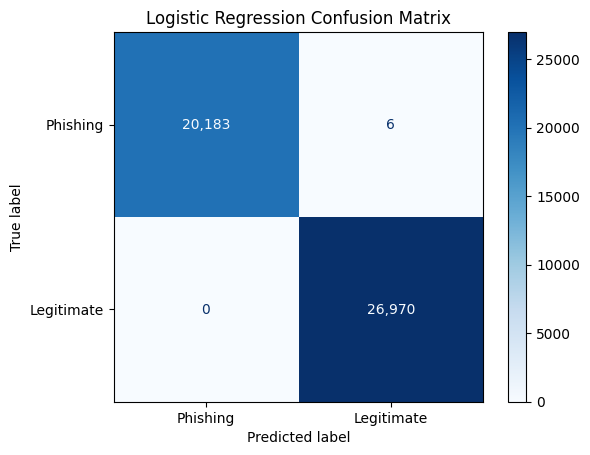

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Phishing", "Legitimate"]
)

display.plot(cmap="Blues", values_format=",")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

phishing_precision = precision_score(
    y_test,
    y_pred,
    pos_label=0
)

phishing_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

phishing_f1 = f1_score(
    y_test,
    y_pred,
    pos_label=0
)

print("Phishing precision:", round(phishing_precision, 4))
print("Phishing recall:", round(phishing_recall, 4))
print("Phishing F1-score:", round(phishing_f1, 4))

Phishing precision: 1.0
Phishing recall: 0.9997
Phishing F1-score: 0.9999


In [25]:
training_analysis = X_train.copy()
training_analysis["label"] = y_train

feature_correlations = (
    training_analysis
    .corr(numeric_only=True)["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

print("Features most strongly correlated with the label:")
print(feature_correlations.head(15))

Features most strongly correlated with the label:
URLSimilarityIndex       0.860443
HasSocialNet             0.783682
HasCopyrightInfo         0.742820
HasDescription           0.690587
IsHTTPS                  0.609105
DomainTitleMatchScore    0.583463
HasSubmitButton          0.578994
IsResponsive             0.548483
URLTitleMatchScore       0.538363
SpacialCharRatioInURL   -0.533748
HasHiddenFields          0.507307
HasFavicon               0.493375
URLCharProb              0.470242
CharContinuationRate     0.467198
HasTitle                 0.459890
Name: label, dtype: float64


In [26]:
model_coefficients = pd.Series(
    logistic_model.named_steps["classifier"].coef_[0],
    index=X_train.columns
)

important_coefficients = model_coefficients.reindex(
    model_coefficients.abs().sort_values(ascending=False).index
)

print("Most influential Logistic Regression features:")
print(important_coefficients.head(15))

Most influential Logistic Regression features:
URLSimilarityIndex       7.144740
IsHTTPS                  3.910232
SpacialCharRatioInURL   -1.888559
LetterRatioInURL        -1.750995
NoOfSelfRef              1.637538
NoOfJS                   1.598587
HasSocialNet             1.485065
NoOfExternalRef          1.428235
NoOfImage                1.336070
DegitRatioInURL         -1.269880
NoOfSubDomain            1.235244
LineOfCode               1.151420
DomainLength             1.129755
LargestLineLength       -1.037715
HasCopyrightInfo         0.945294
dtype: float64


In [27]:
numeric_duplicate_count = X_numeric.duplicated().sum()

print(
    "Duplicate rows based only on numeric features:",
    numeric_duplicate_count
)

Duplicate rows based only on numeric features: 808


In [28]:
print("Total domain entries:", len(df))
print("Unique domains:", df["Domain"].nunique())
print("Repeated domain entries:", df["Domain"].duplicated().sum())

Total domain entries: 235795
Unique domains: 220086
Repeated domain entries: 15709


### Initial Logistic Regression Observation

The Logistic Regression baseline achieved near-perfect phishing-class
precision, recall and F1-score. Although this indicates that the available
numeric features are highly predictive, the result should not immediately
be interpreted as equivalent real-world performance.

Additional investigation is required to identify highly label-correlated
features, repeated numeric patterns, domain overlap and potential target
leakage. A stricter evaluation using previously unseen domains will also
be considered.

In [29]:
training_analysis = X_train.copy()
training_analysis["label"] = y_train

feature_correlations = (
    training_analysis
    .corr(numeric_only=True)["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

print("Top 15 features correlated with the target:")
print(feature_correlations.head(15))

Top 15 features correlated with the target:
URLSimilarityIndex       0.860443
HasSocialNet             0.783682
HasCopyrightInfo         0.742820
HasDescription           0.690587
IsHTTPS                  0.609105
DomainTitleMatchScore    0.583463
HasSubmitButton          0.578994
IsResponsive             0.548483
URLTitleMatchScore       0.538363
SpacialCharRatioInURL   -0.533748
HasHiddenFields          0.507307
HasFavicon               0.493375
URLCharProb              0.470242
CharContinuationRate     0.467198
HasTitle                 0.459890
Name: label, dtype: float64


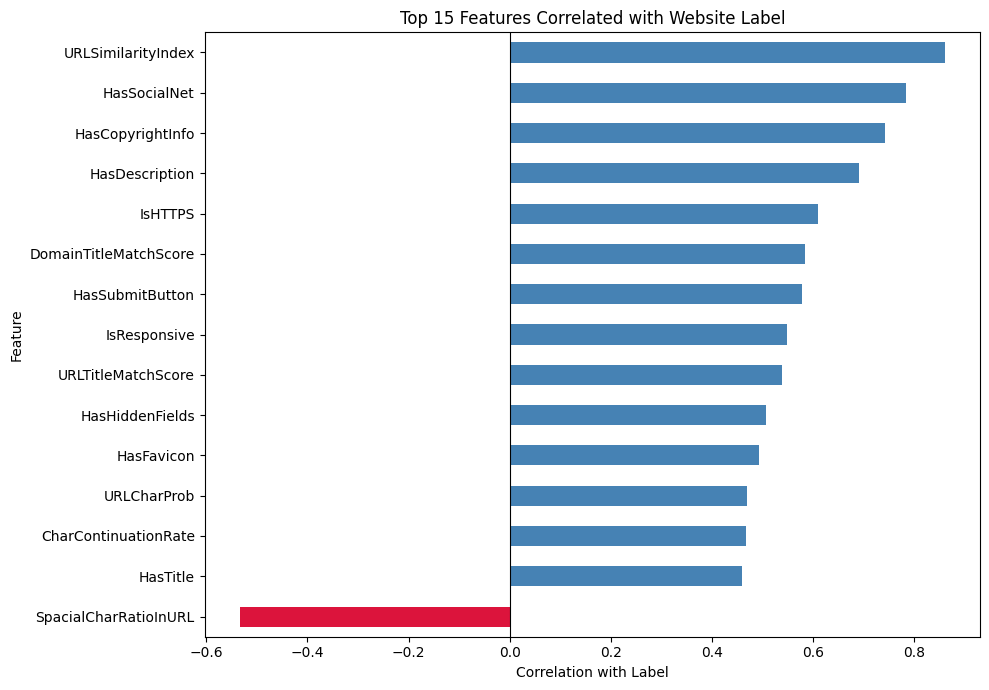

In [30]:
top_correlations = feature_correlations.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_correlations.plot(
    kind="barh",
    color=[
        "crimson" if value < 0 else "steelblue"
        for value in top_correlations
    ]
)

plt.title("Top 15 Features Correlated with Website Label")
plt.xlabel("Correlation with Label")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Logistic Regression Baseline Results

The Logistic Regression baseline correctly classified 47,153 of the
47,159 test observations, producing an accuracy of approximately 99.99%.

The model correctly identified 20,183 phishing websites and all 26,970
legitimate websites. Six phishing websites were incorrectly classified
as legitimate, while no legitimate websites were incorrectly flagged
as phishing.

Although the initial results are highly promising, performance this
close to 100% may indicate exceptionally predictive engineered features,
overlap between related observations, or possible target leakage.
Therefore, feature correlations, influential model coefficients,
repeated feature patterns and domain overlap require further
investigation before making conclusions about real-world performance.

In [31]:
model_coefficients = pd.Series(
    logistic_model.named_steps["classifier"].coef_[0],
    index=X_train.columns
)

important_coefficients = model_coefficients.reindex(
    model_coefficients.abs().sort_values(ascending=False).index
)

print("Top 15 influential model features:")
print(important_coefficients.head(15).round(4))

Top 15 influential model features:
URLSimilarityIndex       7.1447
IsHTTPS                  3.9102
SpacialCharRatioInURL   -1.8886
LetterRatioInURL        -1.7510
NoOfSelfRef              1.6375
NoOfJS                   1.5986
HasSocialNet             1.4851
NoOfExternalRef          1.4282
NoOfImage                1.3361
DegitRatioInURL         -1.2699
NoOfSubDomain            1.2352
LineOfCode               1.1514
DomainLength             1.1298
LargestLineLength       -1.0377
HasCopyrightInfo         0.9453
dtype: float64


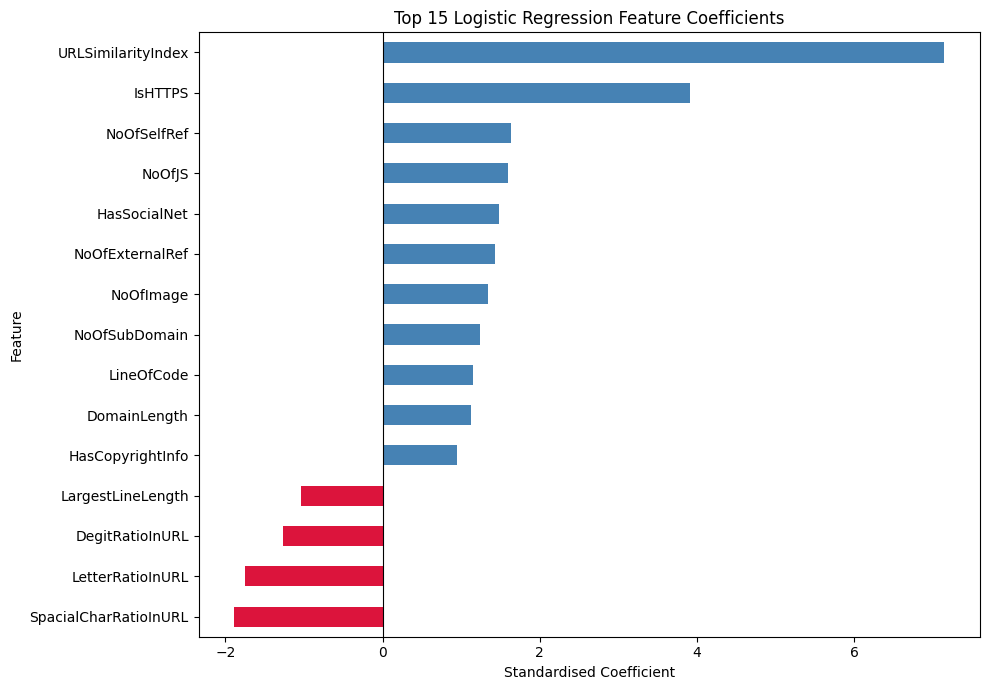

In [32]:
top_coefficients = important_coefficients.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_coefficients.plot(
    kind="barh",
    color=[
        "crimson" if value < 0 else "steelblue"
        for value in top_coefficients
    ]
)

plt.title("Top 15 Logistic Regression Feature Coefficients")
plt.xlabel("Standardised Coefficient")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Feature Correlation Findings

The correlation analysis showed that URLSimilarityIndex had the strongest
positive relationship with the target label. Features such as
HasSocialNet, HasCopyrightInfo, HasDescription and IsHTTPS were also
strongly associated with legitimate websites.

SpacialCharRatioInURL showed the strongest negative relationship,
indicating that URLs containing a greater proportion of special
characters were more strongly associated with phishing websites.

The presence of several highly predictive engineered features may
partially explain the near-perfect Logistic Regression performance.
However, correlation alone does not establish target leakage. Further
analysis of feature definitions, model coefficients, repeated patterns
and domain overlap is required.

In [33]:
X_train_without_similarity = X_train.drop(
    columns=["URLSimilarityIndex"]
)

X_test_without_similarity = X_test.drop(
    columns=["URLSimilarityIndex"]
)

print(
    "Original training shape:",
    X_train.shape
)

print(
    "Reduced training shape:",
    X_train_without_similarity.shape
)

Original training shape: (188636, 50)
Reduced training shape: (188636, 49)


In [34]:
logistic_model_without_similarity = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_model_without_similarity.fit(
    X_train_without_similarity,
    y_train
)

y_pred_without_similarity = (
    logistic_model_without_similarity.predict(
        X_test_without_similarity
    )
)

print("Reduced model training completed.")

Reduced model training completed.


In [35]:
original_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Phishing Precision": precision_score(
        y_test, y_pred, pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test, y_pred, pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test, y_pred, pos_label=0
    )
}

reduced_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_without_similarity
    ),
    "Phishing Precision": precision_score(
        y_test,
        y_pred_without_similarity,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test,
        y_pred_without_similarity,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test,
        y_pred_without_similarity,
        pos_label=0
    )
}

comparison = pd.DataFrame({
    "Original Model": original_results,
    "Without URLSimilarityIndex": reduced_results
}).T

comparison.round(4)

,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
Original Model,0.9999,1.0000,0.9997,0.9999
Without URLSimilarityIndex,0.9992,0.9992,0.9988,0.9990


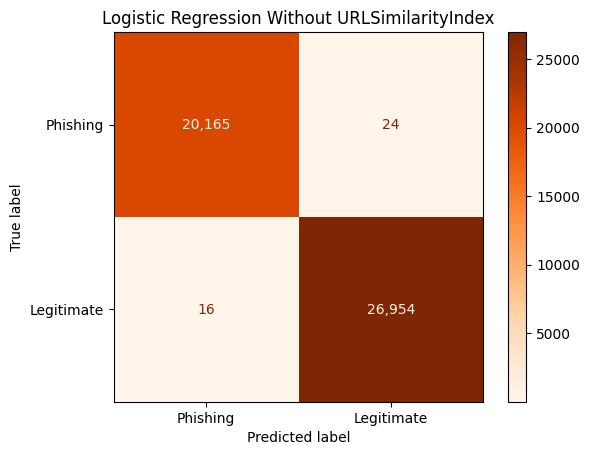

In [36]:
reduced_cm = confusion_matrix(
    y_test,
    y_pred_without_similarity,
    labels=[0, 1]
)

reduced_display = ConfusionMatrixDisplay(
    confusion_matrix=reduced_cm,
    display_labels=["Phishing", "Legitimate"]
)

reduced_display.plot(
    cmap="Oranges",
    values_format=","
)

plt.title(
    "Logistic Regression Without URLSimilarityIndex"
)
plt.show()

### URLSimilarityIndex Ablation Study

To investigate the influence of URLSimilarityIndex, a second Logistic
Regression model was trained after removing this feature.

The original model made six incorrect predictions. After removing
URLSimilarityIndex, the number of incorrect predictions increased to
40, including 24 phishing websites classified as legitimate and 16
legitimate websites classified as phishing.

The reduced model still achieved approximately 99.92% accuracy. This
shows that URLSimilarityIndex contributes meaningfully to performance
but is not solely responsible for the model's high predictive ability.
The remaining engineered features collectively provide strong
separation between phishing and legitimate websites.

In [37]:
train_domains = (
    df.loc[X_train.index, "Domain"]
    .astype(str)
    .str.lower()
    .str.strip()
)

test_domains = (
    df.loc[X_test.index, "Domain"]
    .astype(str)
    .str.lower()
    .str.strip()
)

train_domain_set = set(train_domains)

test_domain_overlap = test_domains.isin(
    train_domain_set
)

print("Unique training domains:", train_domains.nunique())
print("Unique testing domains:", test_domains.nunique())

print(
    "Test rows whose domain appears in training:",
    test_domain_overlap.sum()
)

print(
    "Domain overlap percentage:",
    round(test_domain_overlap.mean() * 100, 2),
    "%"
)

Unique training domains: 176942
Unique testing domains: 45254
Test rows whose domain appears in training: 3830
Domain overlap percentage: 8.12 %


In [38]:
train_urls = (
    df.loc[X_train.index, "URL"]
    .astype(str)
    .str.lower()
    .str.strip()
)

test_urls = (
    df.loc[X_test.index, "URL"]
    .astype(str)
    .str.lower()
    .str.strip()
)

url_overlap = test_urls.isin(set(train_urls))

print("Exact URL overlap:", url_overlap.sum())

print(
    "Exact URL overlap percentage:",
    round(url_overlap.mean() * 100, 2),
    "%"
)

Exact URL overlap: 143
Exact URL overlap percentage: 0.3 %


In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
overlapping_test_indices = test_urls[url_overlap].index

overlapping_url_examples = df.loc[
    overlapping_test_indices,
    ["URL", "Domain", "label"]
]

print(
    overlapping_url_examples.head(10)
)

                                                      URL  \
191089                    https://amfxu3.firebaseapp.com/   
9647                    http://dipartimento-revisone.com/   
198338           https://fbcom-1000321329-review.web.app/   
125356                 https://att-108744.weeblysite.com/   
227446                https://which0x001.firebaseapp.com/   
198231  https://bafybeiaewpscoflbo4lgn4fl4znwdj27nyl2n...   
188473                               http://azuki.com.co/   
224796  https://login-auth-bper-supporto.cfolks.pl/app...   
92976                https://btconnect-6ffbaf.webflow.io/   
132030  https://movehome.life/source/vendor/brick/math...   

                                                   Domain  label  
191089                             amfxu3.firebaseapp.com      0  
9647                            dipartimento-revisone.com      0  
198338                    fbcom-1000321329-review.web.app      0  
125356                          att-108744.weeblysite.com   

In [41]:
url_audit = df[
    ["URL", "Domain", "label"]
].copy()

url_audit["normalized_url"] = (
    url_audit["URL"]
    .astype(str)
    .str.lower()
    .str.strip()
)

url_summary = (
    url_audit
    .groupby("normalized_url")
    .agg(
        row_count=("label", "size"),
        unique_labels=("label", "nunique")
    )
)

print(
    "URLs appearing more than once:",
    (url_summary["row_count"] > 1).sum()
)

print(
    "Repeated URLs with conflicting labels:",
    (url_summary["unique_labels"] > 1).sum()
)

URLs appearing more than once: 425
Repeated URLs with conflicting labels: 0


In [42]:
train_domains = (
    df.loc[X_train.index, "Domain"]
    .astype(str)
    .str.lower()
    .str.strip()
)

test_domains = (
    df.loc[X_test.index, "Domain"]
    .astype(str)
    .str.lower()
    .str.strip()
)

domain_overlap = test_domains.isin(
    set(train_domains)
)

print(
    "Test domains also found in training:",
    domain_overlap.sum()
)

print(
    "Domain overlap percentage:",
    round(domain_overlap.mean() * 100, 2),
    "%"
)

Test domains also found in training: 3830
Domain overlap percentage: 8.12 %


### URL Overlap Analysis

The overlap analysis identified 143 test observations whose normalised
URL also appeared in the training data, representing 0.30% of the test
set.

This indicates that the random split does not provide complete
separation between URLs. Although the overlap is too small to fully
explain the near-perfect model performance, it could introduce a small
degree of evaluation leakage.

A stricter group-based split will therefore be considered so that
related observations, particularly those sharing a domain, cannot
appear in both training and testing sets.

In [43]:
domain_groups = (
    df["Domain"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Total observations:", len(domain_groups))
print("Unique domains:", domain_groups.nunique())

Total observations: 235795
Unique domains: 220086


In [44]:
from sklearn.model_selection import GroupShuffleSplit

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

group_train_positions, group_test_positions = next(
    group_splitter.split(
        X_numeric,
        y,
        groups=domain_groups
    )
)

X_train_group = X_numeric.iloc[
    group_train_positions
].copy()

X_test_group = X_numeric.iloc[
    group_test_positions
].copy()

y_train_group = y.iloc[
    group_train_positions
].copy()

y_test_group = y.iloc[
    group_test_positions
].copy()

print("Grouped X_train:", X_train_group.shape)
print("Grouped X_test:", X_test_group.shape)
print("Grouped y_train:", y_train_group.shape)
print("Grouped y_test:", y_test_group.shape)

Grouped X_train: (189074, 50)
Grouped X_test: (46721, 50)
Grouped y_train: (189074,)
Grouped y_test: (46721,)


In [45]:
group_train_domains = set(
    domain_groups.iloc[group_train_positions]
)

group_test_domains = set(
    domain_groups.iloc[group_test_positions]
)

shared_domains = (
    group_train_domains
    .intersection(group_test_domains)
)

print(
    "Domains shared between grouped sets:",
    len(shared_domains)
)

Domains shared between grouped sets: 0


In [46]:
print("Grouped training distribution:")

print(
    y_train_group
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nGrouped testing distribution:")

print(
    y_test_group
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Grouped training distribution:
label
1    57.08
0    42.92
Name: proportion, dtype: float64

Grouped testing distribution:
label
1    57.63
0    42.37
Name: proportion, dtype: float64


### Domain Overlap Analysis

The random train-test split contained 3,830 test observations whose
domain also occurred in the training set. This represented 8.12% of
the test observations and could cause an optimistic evaluation because
the model was not being assessed exclusively on unseen domains.

To create a stricter evaluation, a group-based split was introduced.
All observations sharing the same normalised domain were assigned
entirely to either training or testing. This prevents domain-level
overlap and provides a more realistic assessment of generalisation to
previously unseen domains.

In [47]:
grouped_logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

grouped_logistic_model.fit(
    X_train_group,
    y_train_group
)

y_pred_group = grouped_logistic_model.predict(
    X_test_group
)

print("Domain-grouped model training completed.")

Domain-grouped model training completed.


In [48]:
grouped_accuracy = accuracy_score(
    y_test_group,
    y_pred_group
)

grouped_phishing_precision = precision_score(
    y_test_group,
    y_pred_group,
    pos_label=0
)

grouped_phishing_recall = recall_score(
    y_test_group,
    y_pred_group,
    pos_label=0
)

grouped_phishing_f1 = f1_score(
    y_test_group,
    y_pred_group,
    pos_label=0
)

print(
    "Grouped accuracy:",
    round(grouped_accuracy, 4)
)

print(
    "Grouped phishing precision:",
    round(grouped_phishing_precision, 4)
)

print(
    "Grouped phishing recall:",
    round(grouped_phishing_recall, 4)
)

print(
    "Grouped phishing F1-score:",
    round(grouped_phishing_f1, 4)
)

Grouped accuracy: 0.9999
Grouped phishing precision: 1.0
Grouped phishing recall: 0.9997
Grouped phishing F1-score: 0.9999


In [49]:
print(
    classification_report(
        y_test_group,
        y_pred_group,
        labels=[0, 1],
        target_names=[
            "Phishing (0)",
            "Legitimate (1)"
        ]
    )
)

                precision    recall  f1-score   support

  Phishing (0)       1.00      1.00      1.00     19798
Legitimate (1)       1.00      1.00      1.00     26923

      accuracy                           1.00     46721
     macro avg       1.00      1.00      1.00     46721
  weighted avg       1.00      1.00      1.00     46721



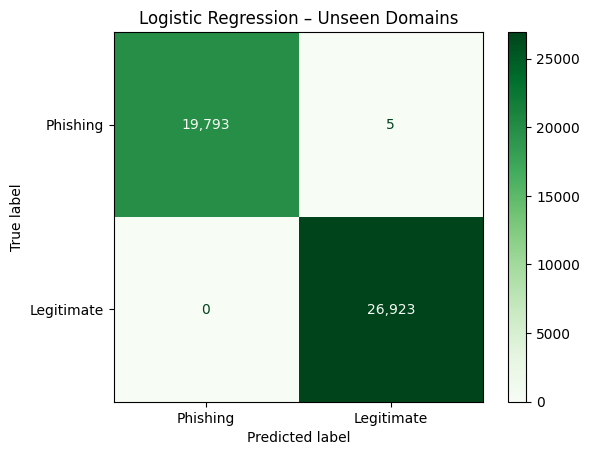

In [50]:
grouped_cm = confusion_matrix(
    y_test_group,
    y_pred_group,
    labels=[0, 1]
)

grouped_display = ConfusionMatrixDisplay(
    confusion_matrix=grouped_cm,
    display_labels=["Phishing", "Legitimate"]
)

grouped_display.plot(
    cmap="Greens",
    values_format=","
)

plt.title(
    "Logistic Regression – Unseen Domains"
)

plt.show()

In [51]:
split_comparison = pd.DataFrame({
    "Random Split": {
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Phishing Precision": precision_score(
            y_test,
            y_pred,
            pos_label=0
        ),
        "Phishing Recall": recall_score(
            y_test,
            y_pred,
            pos_label=0
        ),
        "Phishing F1": f1_score(
            y_test,
            y_pred,
            pos_label=0
        )
    },
    "Domain-Grouped Split": {
        "Accuracy": grouped_accuracy,
        "Phishing Precision": grouped_phishing_precision,
        "Phishing Recall": grouped_phishing_recall,
        "Phishing F1": grouped_phishing_f1
    }
}).T

split_comparison.round(4)

,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
Random Split,0.9999,1.0,0.9997,0.9999
Domain-Grouped Split,0.9999,1.0,0.9997,0.9999


### Random Split versus Domain-Grouped Split

The domain-grouped evaluation produced performance comparable to the
original random split. On 46,721 observations from unseen domains, the
model correctly classified 46,716 observations and made only five
errors. All five errors were phishing websites incorrectly classified
as legitimate.

The grouped model produced no false phishing warnings and achieved
approximately 99.99% accuracy. Because performance remained stable
after preventing domain overlap, the original result was not materially
caused by repeated domains across the training and testing sets.

The results suggest that the dataset's engineered numeric features
provide strong separation between phishing and legitimate websites.
Nevertheless, these results represent performance on a single curated
dataset and should not automatically be interpreted as equivalent
performance on live, temporally changing web data.

In [52]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_group,
    y_train_group
)

y_pred_rf = random_forest_model.predict(
    X_test_group
)

print("Random Forest training completed.")

Random Forest training completed.


In [53]:
rf_accuracy = accuracy_score(
    y_test_group,
    y_pred_rf
)

rf_phishing_precision = precision_score(
    y_test_group,
    y_pred_rf,
    pos_label=0
)

rf_phishing_recall = recall_score(
    y_test_group,
    y_pred_rf,
    pos_label=0
)

rf_phishing_f1 = f1_score(
    y_test_group,
    y_pred_rf,
    pos_label=0
)

print("Random Forest accuracy:", round(rf_accuracy, 4))
print(
    "Random Forest phishing precision:",
    round(rf_phishing_precision, 4)
)
print(
    "Random Forest phishing recall:",
    round(rf_phishing_recall, 4)
)
print(
    "Random Forest phishing F1:",
    round(rf_phishing_f1, 4)
)

Random Forest accuracy: 1.0
Random Forest phishing precision: 1.0
Random Forest phishing recall: 0.9999
Random Forest phishing F1: 0.9999


In [54]:
model_comparison = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": grouped_accuracy,
        "Phishing Precision": grouped_phishing_precision,
        "Phishing Recall": grouped_phishing_recall,
        "Phishing F1": grouped_phishing_f1
    },
    "Random Forest": {
        "Accuracy": rf_accuracy,
        "Phishing Precision": rf_phishing_precision,
        "Phishing Recall": rf_phishing_recall,
        "Phishing F1": rf_phishing_f1
    }
}).T

model_comparison.round(6)

,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
Logistic Regression,0.999893,1.0,0.999747,0.999874
Random Forest,0.999957,1.0,0.999899,0.999949


In [55]:
rf_feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X_train_group.columns
).sort_values(ascending=False)

print("Top 15 Random Forest features:")
print(rf_feature_importance.head(15).round(6))

Top 15 Random Forest features:
URLSimilarityIndex            0.195826
NoOfExternalRef               0.165875
LineOfCode                    0.130954
NoOfImage                     0.112487
NoOfSelfRef                   0.091720
NoOfJS                        0.074663
HasSocialNet                  0.034385
NoOfCSS                       0.030697
HasDescription                0.023109
HasCopyrightInfo              0.022831
NoOfOtherSpecialCharsInURL    0.018137
IsHTTPS                       0.014503
NoOfDegitsInURL               0.013695
LargestLineLength             0.013057
DegitRatioInURL               0.006284
dtype: float64


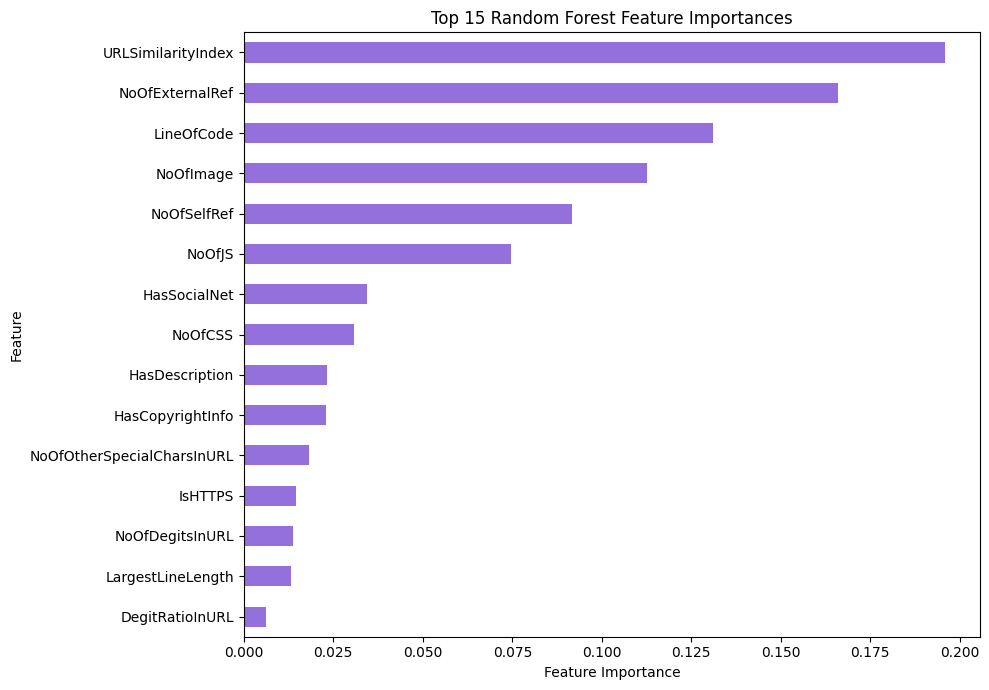

In [56]:
top_rf_features = (
    rf_feature_importance
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

top_rf_features.plot(
    kind="barh",
    color="mediumpurple"
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Random Forest Feature Importance

The Random Forest model identified URLSimilarityIndex as its most
important feature, contributing approximately 19.6% of the model's
built-in feature importance. This was followed by NoOfExternalRef,
LineOfCode, NoOfImage, NoOfSelfRef and NoOfJS.

The six most influential features accounted for approximately 77% of
the model's total importance. This suggests that the model relies on a
combination of URL similarity and webpage-structure characteristics
rather than a single feature.

Random Forest impurity-based importance does not indicate whether a
feature pushes a prediction toward phishing or legitimate, and it may
favour continuous features with many possible split points. Therefore,
the findings require verification using a model-agnostic technique.

In [57]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

sample_size = min(
    5000,
    len(X_test_group)
)

X_permutation_sample = X_test_group.sample(
    n=sample_size,
    random_state=42
)

y_permutation_sample = y_test_group.loc[
    X_permutation_sample.index
]

phishing_f1_scorer = make_scorer(
    f1_score,
    pos_label=0
)

In [58]:
permutation_results = permutation_importance(
    random_forest_model,
    X_permutation_sample,
    y_permutation_sample,
    scoring=phishing_f1_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_permutation_sample.columns,
    "Mean Importance":
        permutation_results.importances_mean,
    "Standard Deviation":
        permutation_results.importances_std
}).sort_values(
    "Mean Importance",
    ascending=False
)

permutation_importance_df.head(15)

,Feature,Mean Importance,Standard Deviation
3,URLSimilarityIndex,0.253794,0.002052
21,IsHTTPS,0.015199,0.001150
22,LineOfCode,0.000291,0.000097
44,NoOfImage,0.000243,0.000000
47,NoOfSelfRef,0.000049,0.000097
5,TLDLegitimateProb,0.000000,0.000000
1,DomainLength,0.000000,0.000000
2,IsDomainIP,0.000000,0.000000
4,CharContinuationRate,0.000000,0.000000
9,HasObfuscation,0.000000,0.000000


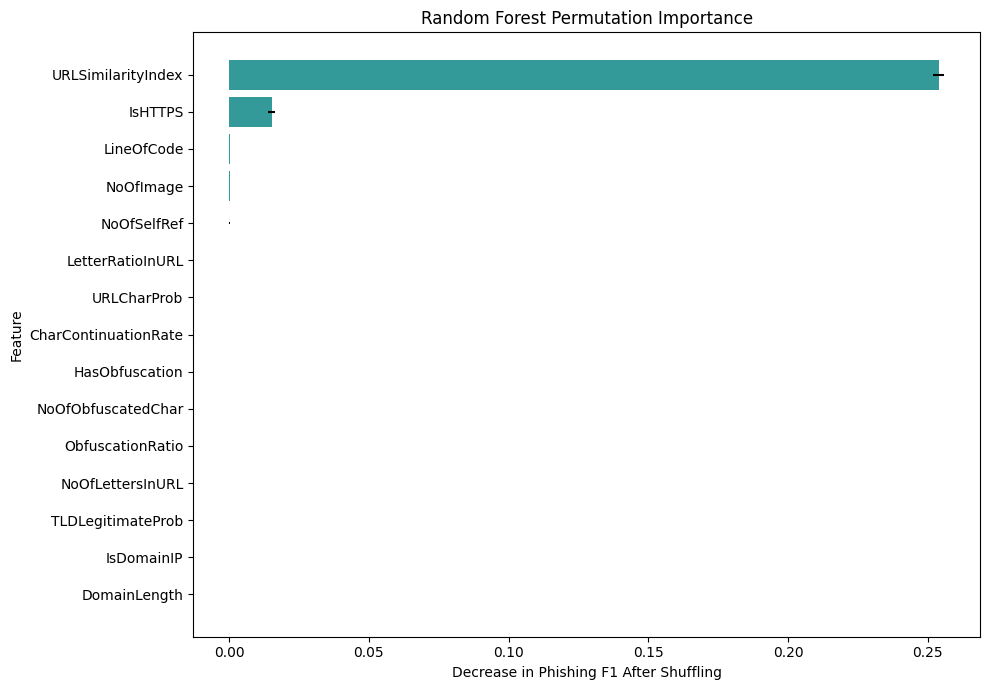

In [59]:
top_permutation_features = (
    permutation_importance_df
    .head(15)
    .sort_values("Mean Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation_features["Feature"],
    top_permutation_features["Mean Importance"],
    xerr=top_permutation_features[
        "Standard Deviation"
    ],
    color="teal",
    alpha=0.8
)

plt.title(
    "Random Forest Permutation Importance"
)

plt.xlabel(
    "Decrease in Phishing F1 After Shuffling"
)

plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Permutation Importance Findings

Permutation importance showed that URLSimilarityIndex had the greatest
unique effect on the Random Forest model. Shuffling this feature reduced
the phishing F1-score by approximately 0.25. IsHTTPS produced a much
smaller performance reduction, while most other features produced
minimal individual changes.

These findings differ from the impurity-based importance results.
Impurity importance measures how frequently and effectively features
were used while constructing the trees, whereas permutation importance
measures the performance reduction caused by disrupting one feature
after training.

The near-zero permutation importance of several features does not
necessarily mean that they contain no predictive information. Their
information may overlap with other correlated features. The results
indicate that the fitted Random Forest depends strongly on
URLSimilarityIndex during prediction.

In [60]:
X_train_group_reduced = X_train_group.drop(
    columns=["URLSimilarityIndex"]
)

X_test_group_reduced = X_test_group.drop(
    columns=["URLSimilarityIndex"]
)

rf_without_similarity = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_without_similarity.fit(
    X_train_group_reduced,
    y_train_group
)

y_pred_rf_reduced = rf_without_similarity.predict(
    X_test_group_reduced
)

In [61]:
rf_reduced_accuracy = accuracy_score(
    y_test_group,
    y_pred_rf_reduced
)

rf_reduced_precision = precision_score(
    y_test_group,
    y_pred_rf_reduced,
    pos_label=0
)

rf_reduced_recall = recall_score(
    y_test_group,
    y_pred_rf_reduced,
    pos_label=0
)

rf_reduced_f1 = f1_score(
    y_test_group,
    y_pred_rf_reduced,
    pos_label=0
)

print(
    "Accuracy:",
    round(rf_reduced_accuracy, 6)
)

print(
    "Phishing precision:",
    round(rf_reduced_precision, 6)
)

print(
    "Phishing recall:",
    round(rf_reduced_recall, 6)
)

print(
    "Phishing F1:",
    round(rf_reduced_f1, 6)
)

Accuracy: 0.999936
Phishing precision: 1.0
Phishing recall: 0.999848
Phishing F1: 0.999924


In [62]:
final_comparison = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": grouped_accuracy,
        "Phishing Precision":
            grouped_phishing_precision,
        "Phishing Recall":
            grouped_phishing_recall,
        "Phishing F1":
            grouped_phishing_f1
    },
    "Random Forest": {
        "Accuracy": rf_accuracy,
        "Phishing Precision":
            rf_phishing_precision,
        "Phishing Recall":
            rf_phishing_recall,
        "Phishing F1":
            rf_phishing_f1
    },
    "RF Without URLSimilarityIndex": {
        "Accuracy": rf_reduced_accuracy,
        "Phishing Precision":
            rf_reduced_precision,
        "Phishing Recall":
            rf_reduced_recall,
        "Phishing F1":
            rf_reduced_f1
    }
}).T

final_comparison.round(6)

,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
Logistic Regression,0.999893,1.0,0.999747,0.999874
Random Forest,0.999957,1.0,0.999899,0.999949
RF Without URLSimilarityIndex,0.999936,1.0,0.999848,0.999924


### Random Forest Ablation Findings

Permutation importance initially indicated that the fitted Random Forest
depended heavily on URLSimilarityIndex. However, after retraining the
model without this feature, performance decreased only slightly.

The complete Random Forest missed two phishing observations, while the
retrained reduced model missed three. Its accuracy remained approximately
99.994%.

This difference demonstrates the distinction between permutation and
ablation analysis. Permutation importance disrupts a feature after the
model has already learned to depend on it. Ablation retraining allows
the algorithm to learn alternative patterns from correlated or redundant
features.

Consequently, URLSimilarityIndex is important to the original fitted
model, but it is not essential for maintaining high performance when
the model is retrained.

In [63]:
url_feature_columns = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

X_train_url = X_train_group[
    url_feature_columns
].copy()

X_test_url = X_test_group[
    url_feature_columns
].copy()

print("URL training shape:", X_train_url.shape)
print("URL testing shape:", X_test_url.shape)

URL training shape: (189074, 18)
URL testing shape: (46721, 18)


In [64]:
url_random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

url_random_forest.fit(
    X_train_url,
    y_train_group
)

y_pred_url = url_random_forest.predict(
    X_test_url
)

In [65]:
url_model_results = {
    "Accuracy": accuracy_score(
        y_test_group,
        y_pred_url
    ),
    "Phishing Precision": precision_score(
        y_test_group,
        y_pred_url,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test_group,
        y_pred_url,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test_group,
        y_pred_url,
        pos_label=0
    )
}

print(
    pd.Series(url_model_results)
    .round(6)
)

Accuracy              0.997539
Phishing Precision    0.998986
Phishing Recall       0.995202
Phishing F1           0.997090
dtype: float64


In [66]:
reproducible_url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "IsHTTPS"
]

X_train_reproducible = X_train_group[
    reproducible_url_features
].copy()

X_test_reproducible = X_test_group[
    reproducible_url_features
].copy()

print(
    "Reproducible training shape:",
    X_train_reproducible.shape
)

print(
    "Reproducible testing shape:",
    X_test_reproducible.shape
)

Reproducible training shape: (189074, 13)
Reproducible testing shape: (46721, 13)


In [67]:
reproducible_url_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

reproducible_url_model.fit(
    X_train_reproducible,
    y_train_group
)

y_pred_reproducible = (
    reproducible_url_model.predict(
        X_test_reproducible
    )
)

In [68]:
reproducible_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test_group,
        y_pred_reproducible
    ),
    "Phishing Precision": precision_score(
        y_test_group,
        y_pred_reproducible,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test_group,
        y_pred_reproducible,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test_group,
        y_pred_reproducible,
        pos_label=0
    )
})

print(
    reproducible_results.round(6)
)

Accuracy              0.997453
Phishing Precision    0.999239
Phishing Recall       0.994747
Phishing F1           0.996988
dtype: float64


### URL-Only Model

A URL-only Random Forest was developed using 18 features that do not
require the prediction service to download and analyse the target
webpage. The model achieved approximately 99.75% accuracy and a
phishing F1-score of approximately 99.71% on previously unseen domains.

This performance was lower than that of the complete feature model but
remained highly competitive. The reduced model is more appropriate for
deployment because it can potentially produce predictions using the URL
alone, reducing latency and avoiding security risks associated with
fetching arbitrary webpages.

Before deployment, the feature-extraction implementation must be
validated against the dataset to prevent differences between training
and production feature calculations.

### Reproducible URL-Feature Model

A second URL-based Random Forest was trained using 13 features that
can potentially be calculated directly from the submitted URL. Features
with unclear or dataset-dependent calculations were excluded to reduce
the risk of training-serving skew.

The model achieved approximately 99.75% accuracy, 99.92% phishing
precision, 99.47% phishing recall and a phishing F1-score of 99.70% on
previously unseen domains.

This represents a small reduction compared with the 18-feature URL
model. However, the 13-feature version is more suitable for building a
reproducible prediction service because its inputs can be generated
without downloading or executing content from the submitted website.

The next stage is to implement and validate the URL feature-extraction
logic against the original dataset before deploying the model.

In [73]:
from urllib.parse import urlsplit
import ipaddress
import re


def extract_url_features(url):
    """
    Extract the 13 URL features used by the reproducible model.
    """

    cleaned_url = str(url).strip()

    # Preserve the original URL for HTTPS detection
    has_explicit_scheme = "://" in cleaned_url

    parseable_url = (
        cleaned_url
        if has_explicit_scheme
        else "http://" + cleaned_url
    )

    parsed_url = urlsplit(parseable_url)

    domain = (
        parsed_url.hostname or ""
    ).lower()

    # Remove the scheme for URL-level length and count features
    url_without_scheme = re.sub(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        "",
        cleaned_url
    )

    try:
        ipaddress.ip_address(domain)
        is_domain_ip = 1
    except ValueError:
        is_domain_ip = 0

    domain_parts = [
        part
        for part in domain.split(".")
        if part
    ]

    tld = (
        domain_parts[-1]
        if domain_parts
        else ""
    )

    number_of_subdomains = max(
        len(domain_parts) - 2,
        0
    )

    url_length = len(url_without_scheme)

    # Count only ASCII letters and digits
    number_of_letters = len(
        re.findall(
            r"[A-Za-z]",
            url_without_scheme
        )
    )

    number_of_digits = len(
        re.findall(
            r"[0-9]",
            url_without_scheme
        )
    )

    # Dataset ratios appear to use percentages
    letter_ratio = (
        number_of_letters / url_length * 100
        if url_length > 0
        else 0
    )

    digit_ratio = (
        number_of_digits / url_length * 100
        if url_length > 0
        else 0
    )

    features = {
        "URLLength": url_length,
        "DomainLength": len(domain),
        "IsDomainIP": is_domain_ip,
        "TLDLength": len(tld),
        "NoOfSubDomain": number_of_subdomains,
        "NoOfLettersInURL": number_of_letters,
        "LetterRatioInURL": letter_ratio,
        "NoOfDegitsInURL": number_of_digits,
        "DegitRatioInURL": digit_ratio,
        "NoOfEqualsInURL":
            url_without_scheme.count("="),
        "NoOfQMarkInURL":
            url_without_scheme.count("?"),
        "NoOfAmpersandInURL":
            url_without_scheme.count("&"),
        "IsHTTPS": int(
            parsed_url.scheme.lower() == "https"
        )
    }

    return pd.DataFrame(
        [features],
        columns=reproducible_url_features
    )

In [74]:
calculated_features = pd.concat(
    [
        extract_url_features(url)
        for url in validation_sample["URL"]
    ],
    ignore_index=True
)

expected_features = (
    validation_sample[
        reproducible_url_features
    ]
    .reset_index(drop=True)
)

feature_match_rates = {}

for column in reproducible_url_features:
    feature_match_rates[column] = np.isclose(
        calculated_features[column],
        expected_features[column],
        rtol=1e-4,
        atol=1e-4
    ).mean()

match_rate_table = (
    pd.Series(
        feature_match_rates,
        name="Match Rate"
    )
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

print(match_rate_table)

DomainLength          100.0
TLDLength             100.0
IsDomainIP            100.0
NoOfSubDomain         100.0
NoOfQMarkInURL        100.0
IsHTTPS                99.9
NoOfEqualsInURL        99.9
NoOfDegitsInURL        99.6
NoOfAmpersandInURL     98.9
DegitRatioInURL        79.6
NoOfLettersInURL       21.0
URLLength               0.0
LetterRatioInURL        0.0
Name: Match Rate, dtype: float64


In [75]:
comparison_debug = pd.DataFrame({
    "URL": validation_sample[
        "URL"
    ].reset_index(drop=True),

    "Expected URLLength":
        expected_features["URLLength"],

    "Calculated URLLength":
        calculated_features["URLLength"],

    "Expected Letters":
        expected_features["NoOfLettersInURL"],

    "Calculated Letters":
        calculated_features["NoOfLettersInURL"],

    "Expected Letter Ratio":
        expected_features["LetterRatioInURL"],

    "Calculated Letter Ratio":
        calculated_features["LetterRatioInURL"]
})

mismatched_rows = comparison_debug[
    (
        comparison_debug["Expected URLLength"]
        != comparison_debug["Calculated URLLength"]
    )
    |
    (
        comparison_debug["Expected Letters"]
        != comparison_debug["Calculated Letters"]
    )
]

mismatched_rows.head(10)

,URL,Expected URLLength,Calculated URLLength,Expected Letters,Calculated Letters,Expected Letter Ratio,Calculated Letter Ratio
0,https://www.northcm.ac.th,24,17,10,14,0.417,82.352941
1,https://unitedmartialartscenters.com/at0/mygov...,59,52,45,46,0.763,88.461538
2,https://email.mail1.onesignal.os.tc/c/ejwcz02u...,385,377,302,302,0.784,80.106101
3,http://uqr.to/1il1z,19,12,8,8,0.421,66.666667
4,https://www.woolworthsrewards.com.au,35,28,21,25,0.600,89.285714
5,https://www.kubiena-kochblog.com,31,24,17,21,0.548,87.500000
6,https://couchjumper.com/covantage/index.html,44,36,32,32,0.727,88.888889
7,http://www.rightnowscope.com,27,21,15,19,0.556,90.476190
8,http://u1965047.plsk.regruhosting.ru/47/,40,33,19,19,0.475,57.575758
9,http://www.unblock-me.org,24,18,11,15,0.458,83.333333


In [76]:
from urllib.parse import urlsplit
import ipaddress
import re


engineered_feature_names = [
    "url_length",
    "domain_length",
    "is_domain_ip",
    "tld_length",
    "subdomain_count",
    "letter_count",
    "letter_ratio",
    "digit_count",
    "digit_ratio",
    "equals_count",
    "question_mark_count",
    "ampersand_count",
    "is_https"
]


def extract_engineered_features(url):
    """
    Extract reproducible lexical features from one URL.

    This exact function will be reused by the prediction API.
    """

    cleaned_url = str(url).strip()

    parseable_url = (
        cleaned_url
        if "://" in cleaned_url
        else "http://" + cleaned_url
    )

    parsed = urlsplit(parseable_url)

    domain = (
        parsed.hostname or ""
    ).lower()

    try:
        ipaddress.ip_address(domain)
        is_domain_ip = 1
    except ValueError:
        is_domain_ip = 0

    domain_parts = [
        part
        for part in domain.split(".")
        if part
    ]

    tld = (
        domain_parts[-1]
        if domain_parts and not is_domain_ip
        else ""
    )

    subdomain_count = (
        max(len(domain_parts) - 2, 0)
        if not is_domain_ip
        else 0
    )

    url_length = len(cleaned_url)

    letter_count = len(
        re.findall(
            r"[A-Za-z]",
            cleaned_url
        )
    )

    digit_count = len(
        re.findall(
            r"[0-9]",
            cleaned_url
        )
    )

    letter_ratio = (
        letter_count / url_length
        if url_length > 0
        else 0.0
    )

    digit_ratio = (
        digit_count / url_length
        if url_length > 0
        else 0.0
    )

    return {
        "url_length": url_length,
        "domain_length": len(domain),
        "is_domain_ip": is_domain_ip,
        "tld_length": len(tld),
        "subdomain_count": subdomain_count,
        "letter_count": letter_count,
        "letter_ratio": letter_ratio,
        "digit_count": digit_count,
        "digit_ratio": digit_ratio,
        "equals_count": cleaned_url.count("="),
        "question_mark_count": cleaned_url.count("?"),
        "ampersand_count": cleaned_url.count("&"),
        "is_https": int(
            parsed.scheme.lower() == "https"
        )
    }

In [77]:
example_url = (
    "https://example.com/login"
    "?user=123&verify=true"
)

example_result = extract_engineered_features(
    example_url
)

pd.Series(example_result)

,0
url_length,46.000000
domain_length,11.000000
is_domain_ip,0.000000
tld_length,3.000000
subdomain_count,0.000000
letter_count,34.000000
letter_ratio,0.739130
digit_count,3.000000
digit_ratio,0.065217
equals_count,2.000000


In [78]:
engineered_X = pd.DataFrame.from_records(
    [
        extract_engineered_features(url)
        for url in df["URL"]
    ],
    columns=engineered_feature_names
)

print(
    "Engineered feature shape:",
    engineered_X.shape
)

engineered_X.head()

Engineered feature shape: (235795, 13)


,url_length,domain_length,is_domain_ip,tld_length,subdomain_count,letter_count,letter_ratio,digit_count,digit_ratio,equals_count,question_mark_count,ampersand_count,is_https
0,32,24,0,3,1,27,0.843750,0,0.0,0,0,0,1
1,24,16,0,2,1,18,0.750000,0,0.0,0,0,0,1
2,30,22,0,2,2,24,0.800000,0,0.0,0,0,0,1
3,27,19,0,3,1,22,0.814815,0,0.0,0,0,0,1
4,34,26,0,3,1,29,0.852941,0,0.0,0,0,0,1


In [79]:
print(
    engineered_X.isnull()
    .sum()
)

print(
    engineered_X.dtypes
)

url_length             0
domain_length          0
is_domain_ip           0
tld_length             0
subdomain_count        0
letter_count           0
letter_ratio           0
digit_count            0
digit_ratio            0
equals_count           0
question_mark_count    0
ampersand_count        0
is_https               0
dtype: int64
url_length               int64
domain_length            int64
is_domain_ip             int64
tld_length               int64
subdomain_count          int64
letter_count             int64
letter_ratio           float64
digit_count              int64
digit_ratio            float64
equals_count             int64
question_mark_count      int64
ampersand_count          int64
is_https                 int64
dtype: object


In [80]:
X_train_engineered = engineered_X.iloc[
    group_train_positions
].copy()

X_test_engineered = engineered_X.iloc[
    group_test_positions
].copy()

y_train_engineered = y.iloc[
    group_train_positions
].copy()

y_test_engineered = y.iloc[
    group_test_positions
].copy()

print(
    "Training shape:",
    X_train_engineered.shape
)

print(
    "Testing shape:",
    X_test_engineered.shape
)

Training shape: (189074, 13)
Testing shape: (46721, 13)


In [81]:
production_candidate_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

production_candidate_model.fit(
    X_train_engineered,
    y_train_engineered
)

y_pred_production = (
    production_candidate_model.predict(
        X_test_engineered
    )
)

In [82]:
production_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test_engineered,
        y_pred_production
    ),
    "Phishing Precision": precision_score(
        y_test_engineered,
        y_pred_production,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test_engineered,
        y_pred_production,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test_engineered,
        y_pred_production,
        pos_label=0
    )
})

print(
    production_results.round(6)
)

Accuracy              0.994949
Phishing Precision    0.995692
Phishing Recall       0.992373
Phishing F1           0.994030
dtype: float64


### Reproducible Production Candidate

The final URL-only feature set was generated directly from the raw URL
strings using a custom feature-extraction function. The same function
can therefore be reused during API inference, eliminating reliance on
undocumented precomputed dataset features.

On the unseen-domain test set, the resulting Random Forest achieved
approximately 99.49% accuracy, 99.57% phishing precision, 99.24%
phishing recall and a phishing F1-score of 99.40%.

The result is slightly lower than models trained using the dataset's
precomputed features. However, this model represents a more credible
deployment candidate because every feature has a documented
implementation and training-serving consistency can be maintained.

The model uses URL-level lexical analysis only and does not access the
submitted webpage, reducing latency and avoiding the security risks of
fetching arbitrary external content.

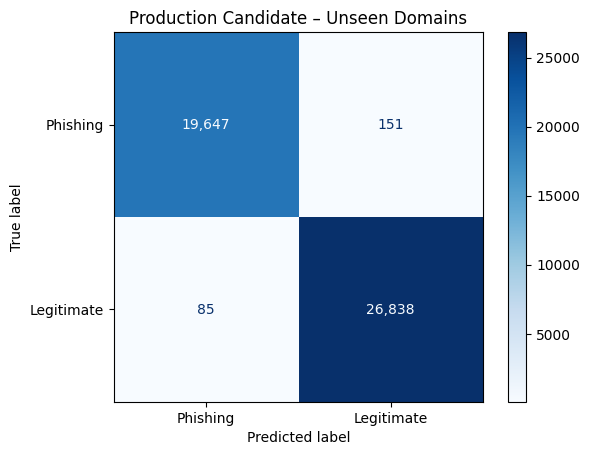

In [83]:
production_cm = confusion_matrix(
    y_test_engineered,
    y_pred_production,
    labels=[0, 1]
)

production_display = ConfusionMatrixDisplay(
    confusion_matrix=production_cm,
    display_labels=["Phishing", "Legitimate"]
)

production_display.plot(
    cmap="Blues",
    values_format=","
)

plt.title(
    "Production Candidate – Unseen Domains"
)

plt.show()

In [84]:
phishing_class_position = list(
    production_candidate_model.classes_
).index(0)

phishing_probabilities = (
    production_candidate_model.predict_proba(
        X_test_engineered
    )[:, phishing_class_position]
)

print(
    "First ten phishing probabilities:"
)

print(
    phishing_probabilities[:10]
)

First ten phishing probabilities:
[0.00529598 0.00529598 0.00794179 0.01116319 0.00780067 0.0071932
 0.03447076 0.96535452 0.99824937 0.00529689]


In [85]:
from sklearn.metrics import precision_recall_curve

y_test_phishing = (
    y_test_engineered == 0
).astype(int)

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_test_phishing,
        phishing_probabilities
    )
)

threshold_results = pd.DataFrame({
    "Threshold": thresholds,
    "Phishing Precision": precision_values[:-1],
    "Phishing Recall": recall_values[:-1]
})

threshold_results.head()

,Threshold,Phishing Precision,Phishing Recall
0,0.001833,0.423749,1.0
1,0.002532,0.426102,1.0
2,0.003116,0.428723,1.0
3,0.003225,0.429011,1.0
4,0.003367,0.434376,1.0


In [86]:
eligible_thresholds = threshold_results[
    threshold_results["Phishing Recall"] >= 0.995
]

selected_threshold_row = (
    eligible_thresholds
    .sort_values(
        "Phishing Precision",
        ascending=False
    )
    .iloc[0]
)

selected_threshold = selected_threshold_row[
    "Threshold"
]

print(
    selected_threshold_row.round(6)
)

Threshold             0.070596
Phishing Precision    0.955522
Phishing Recall       0.995050
Name: 312, dtype: float64


In [87]:
y_pred_tuned = np.where(
    phishing_probabilities >= selected_threshold,
    0,
    1
)

tuned_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test_engineered,
        y_pred_tuned
    ),
    "Phishing Precision": precision_score(
        y_test_engineered,
        y_pred_tuned,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test_engineered,
        y_pred_tuned,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test_engineered,
        y_pred_tuned,
        pos_label=0
    )
})

print(tuned_results.round(6))
print("\nSelected threshold:", selected_threshold)

Accuracy              0.978275
Phishing Precision    0.955522
Phishing Recall       0.995050
Phishing F1           0.974886
dtype: float64

Selected threshold: 0.07059631322633664


In [88]:
inner_groups = domain_groups.iloc[
    group_train_positions
]

validation_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

fit_positions, validation_positions = next(
    validation_splitter.split(
        X_train_engineered,
        y_train_engineered,
        groups=inner_groups
    )
)

X_fit = X_train_engineered.iloc[
    fit_positions
].copy()

X_validation = X_train_engineered.iloc[
    validation_positions
].copy()

y_fit = y_train_engineered.iloc[
    fit_positions
].copy()

y_validation = y_train_engineered.iloc[
    validation_positions
].copy()

print("Model-fitting set:", X_fit.shape)
print("Validation set:", X_validation.shape)
print("Untouched test set:", X_test_engineered.shape)

Model-fitting set: (151864, 13)
Validation set: (37210, 13)
Untouched test set: (46721, 13)


In [89]:
fit_domains = set(
    inner_groups.iloc[fit_positions]
)

validation_domains = set(
    inner_groups.iloc[validation_positions]
)

test_domains_grouped = set(
    domain_groups.iloc[group_test_positions]
)

print(
    "Fit-validation overlap:",
    len(fit_domains.intersection(validation_domains))
)

print(
    "Fit-test overlap:",
    len(fit_domains.intersection(test_domains_grouped))
)

print(
    "Validation-test overlap:",
    len(validation_domains.intersection(test_domains_grouped))
)

Fit-validation overlap: 0
Fit-test overlap: 0
Validation-test overlap: 0


In [90]:
threshold_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

threshold_model.fit(
    X_fit,
    y_fit
)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [91]:
phishing_position = list(
    threshold_model.classes_
).index(0)

validation_phishing_probabilities = (
    threshold_model.predict_proba(
        X_validation
    )[:, phishing_position]
)

y_validation_phishing = (
    y_validation == 0
).astype(int)

validation_precision, validation_recall, validation_thresholds = (
    precision_recall_curve(
        y_validation_phishing,
        validation_phishing_probabilities
    )
)

validation_threshold_table = pd.DataFrame({
    "Threshold": validation_thresholds,
    "Phishing Precision": validation_precision[:-1],
    "Phishing Recall": validation_recall[:-1]
})

eligible_validation_thresholds = (
    validation_threshold_table[
        validation_threshold_table[
            "Phishing Recall"
        ] >= 0.995
    ]
)

selected_validation_row = (
    eligible_validation_thresholds
    .sort_values(
        [
            "Phishing Precision",
            "Threshold"
        ],
        ascending=[False, False]
    )
    .iloc[0]
)

final_threshold = selected_validation_row[
    "Threshold"
]

print(selected_validation_row.round(6))

Threshold             0.020901
Phishing Precision    0.841128
Phishing Recall       0.995052
Name: 104, dtype: float64


In [92]:
test_phishing_probabilities = (
    threshold_model.predict_proba(
        X_test_engineered
    )[:, phishing_position]
)

y_pred_final_threshold = np.where(
    test_phishing_probabilities >= final_threshold,
    0,
    1
)

final_threshold_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test_engineered,
        y_pred_final_threshold
    ),
    "Phishing Precision": precision_score(
        y_test_engineered,
        y_pred_final_threshold,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test_engineered,
        y_pred_final_threshold,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test_engineered,
        y_pred_final_threshold,
        pos_label=0
    )
})

print(final_threshold_results.round(6))
print("\nValidation-selected threshold:", final_threshold)

Accuracy              0.917018
Phishing Precision    0.837954
Phishing Recall       0.996969
Phishing F1           0.910571
dtype: float64

Validation-selected threshold: 0.02090084888078098


### Recall-Oriented Threshold Evaluation

A decision threshold was selected using the validation set with a target
phishing recall of at least 99.5%. The resulting threshold was
approximately 0.0209.

On the untouched test set, this threshold increased phishing recall from
approximately 99.24% to 99.70%. However, phishing precision decreased
from approximately 99.57% to 83.80%, overall accuracy decreased to
91.70%, and phishing F1-score decreased to 91.06%.

The threshold caught approximately 91 additional phishing websites but
generated approximately 3,732 additional false phishing warnings. This
trade-off was considered unsuitable for the primary user-facing
application because excessive false warnings could reduce user trust
and create alert fatigue.

Consequently, the recall-oriented threshold is retained as an
experimental high-security operating mode rather than the default
decision policy.

In [93]:
validation_f1_values = (
    2
    * validation_precision[:-1]
    * validation_recall[:-1]
    /
    (
        validation_precision[:-1]
        + validation_recall[:-1]
        + 1e-12
    )
)

best_f1_position = np.argmax(
    validation_f1_values
)

balanced_threshold = (
    validation_thresholds[
        best_f1_position
    ]
)

print(
    "Balanced validation threshold:",
    balanced_threshold
)

print(
    "Validation precision:",
    validation_precision[
        best_f1_position
    ]
)

print(
    "Validation recall:",
    validation_recall[
        best_f1_position
    ]
)

print(
    "Validation F1:",
    validation_f1_values[
        best_f1_position
    ]
)

Balanced validation threshold: 0.6031956370357153
Validation precision: 0.9981187155368147
Validation recall: 0.9886268714258176
Validation F1: 0.9933501194391023


In [94]:
y_pred_balanced = np.where(
    test_phishing_probabilities
    >= balanced_threshold,
    0,
    1
)

balanced_test_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test_engineered,
        y_pred_balanced
    ),
    "Phishing Precision": precision_score(
        y_test_engineered,
        y_pred_balanced,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test_engineered,
        y_pred_balanced,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test_engineered,
        y_pred_balanced,
        pos_label=0
    )
})

print(
    balanced_test_results.round(6)
)

print(
    "\nBalanced threshold:",
    balanced_threshold
)

Accuracy              0.995206
Phishing Precision    0.997206
Phishing Recall       0.991464
Phishing F1           0.994327
dtype: float64

Balanced threshold: 0.6031956370357153


In [95]:
threshold_comparison = pd.DataFrame({
    "Default 0.50": {
        "Accuracy": production_results[
            "Accuracy"
        ],
        "Phishing Precision": production_results[
            "Phishing Precision"
        ],
        "Phishing Recall": production_results[
            "Phishing Recall"
        ],
        "Phishing F1": production_results[
            "Phishing F1"
        ]
    },
    "Balanced Validation F1": {
        "Accuracy": balanced_test_results[
            "Accuracy"
        ],
        "Phishing Precision": balanced_test_results[
            "Phishing Precision"
        ],
        "Phishing Recall": balanced_test_results[
            "Phishing Recall"
        ],
        "Phishing F1": balanced_test_results[
            "Phishing F1"
        ]
    },
    "High-Recall Mode": {
        "Accuracy": final_threshold_results[
            "Accuracy"
        ],
        "Phishing Precision": final_threshold_results[
            "Phishing Precision"
        ],
        "Phishing Recall": final_threshold_results[
            "Phishing Recall"
        ],
        "Phishing F1": final_threshold_results[
            "Phishing F1"
        ]
    }
}).T

threshold_comparison.round(6)

,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
Default 0.50,0.994949,0.995692,0.992373,0.994030
Balanced Validation F1,0.995206,0.997206,0.991464,0.994327
High-Recall Mode,0.917018,0.837954,0.996969,0.910571


In [96]:
import joblib

model_package = {
    "model": production_candidate_model,
    "threshold": 0.50,
    "feature_names": engineered_feature_names,
    "label_mapping": {
        0: "phishing",
        1: "legitimate"
    },
    "model_version": "1.0.0"
}

joblib.dump(
    model_package,
    "phishing_url_model.joblib"
)

print("Model package saved successfully.")

Model package saved successfully.


In [97]:
import os

print(
    "Model file exists:",
    os.path.exists(
        "phishing_url_model.joblib"
    )
)

print(
    "Model size:",
    round(
        os.path.getsize(
            "phishing_url_model.joblib"
        ) / (1024 * 1024),
        2
    ),
    "MB"
)

Model file exists: True
Model size: 24.75 MB


In [98]:
loaded_package = joblib.load(
    "phishing_url_model.joblib"
)

loaded_model = loaded_package["model"]

print(
    "Loaded model:",
    type(loaded_model).__name__
)

print(
    "Version:",
    loaded_package["model_version"]
)

print(
    "Threshold:",
    loaded_package["threshold"]
)

Loaded model: RandomForestClassifier
Version: 1.0.0
Threshold: 0.5


In [123]:
test_output = extract_engineered_features(
    "https://www.adelaide.edu.au"
)

print("Type:", type(test_output))
print("Output:", test_output)

if hasattr(test_output, "shape"):
    print("Shape:", test_output.shape)

if isinstance(test_output, (list, tuple)):
    print("Outer length:", len(test_output))

    if len(test_output) > 0:
        print("First item type:", type(test_output[0]))
        print("First item:", test_output[0])

Type: <class 'NoneType'>
Output: None


In [121]:
def predict_url(url):
    extracted = extract_engineered_features(url)
    feature_names = model_package["feature_names"]

    # Handle whichever format the extractor returns.
    if isinstance(extracted, pd.DataFrame):
        feature_frame = extracted.copy()

    elif isinstance(extracted, pd.Series):
        feature_frame = extracted.to_frame().T

    elif isinstance(extracted, dict):
        feature_frame = pd.DataFrame([extracted])

    else:
        feature_frame = pd.DataFrame(
            [extracted],
            columns=feature_names
        )

    # Ensure identical feature order to model training.
    feature_frame = feature_frame[feature_names]

    phishing_class_position = list(
        model_package["model"].classes_
    ).index(0)

    phishing_score = model_package["model"].predict_proba(
        feature_frame
    )[0, phishing_class_position]

    threshold = model_package["threshold"]

    prediction = (
        "phishing"
        if phishing_score >= threshold
        else "legitimate"
    )

    return {
        "url": url,
        "canonical_url": canonicalize_url(url),
        "prediction": prediction,
        "phishing_score": round(float(phishing_score), 4),
        "threshold": threshold,
        "model_version": model_package["model_version"]
    }

In [145]:
pd.DataFrame([
    predict_url("https://www.adelaide.edu.au"),
    predict_url("https://www.adelaide.edu.au/")
])

,url,canonical_url,prediction,phishing_score,threshold,model_version
0,https://www.adelaide.edu.au,https://www.adelaide.edu.au,legitimate,0.0195,0.5,1.1.0
1,https://www.adelaide.edu.au/,https://www.adelaide.edu.au,legitimate,0.0195,0.5,1.1.0


In [102]:
adelaide_url = (
    "https://www.adelaide.edu.au/"
)

adelaide_features = (
    extract_engineered_features(
        adelaide_url
    )
)

pd.Series(adelaide_features)

,0
url_length,28.00
domain_length,19.00
is_domain_ip,0.00
tld_length,2.00
subdomain_count,2.00
letter_count,21.00
letter_ratio,0.75
digit_count,0.00
digit_ratio,0.00
equals_count,0.00


In [103]:
test_urls = [
    "https://www.adelaide.edu.au/",
    "https://adelaide.edu.au/",
    "http://www.adelaide.edu.au/",
    "www.adelaide.edu.au",
    "https://www.google.com/",
    "https://www.microsoft.com/",
    "https://www.github.com/"
]

sanity_results = pd.DataFrame(
    [
        predict_url(url)
        for url in test_urls
    ]
)

sanity_results

,url,prediction,phishing_score,threshold,model_version
0,https://www.adelaide.edu.au/,phishing,0.6941,0.5,1.0.0
1,https://adelaide.edu.au/,phishing,0.6616,0.5,1.0.0
2,http://www.adelaide.edu.au/,phishing,1.0000,0.5,1.0.0
3,www.adelaide.edu.au,phishing,0.9754,0.5,1.0.0
4,https://www.google.com/,phishing,0.7491,0.5,1.0.0
5,https://www.microsoft.com/,phishing,0.8011,0.5,1.0.0
6,https://www.github.com/,phishing,0.7491,0.5,1.0.0


In [104]:
education_au_rows = df[
    df["Domain"]
    .astype(str)
    .str.lower()
    .str.endswith(".edu.au")
]

print(
    "Number of .edu.au observations:",
    len(education_au_rows)
)

print(
    "Label distribution:"
)

print(
    education_au_rows[
        "label"
    ].value_counts()
)

Number of .edu.au observations: 169
Label distribution:
label
1    162
0      7
Name: count, dtype: int64


In [105]:
adelaide_rows = df[
    df["Domain"]
    .astype(str)
    .str.lower()
    .str.contains(
        "adelaide.edu.au",
        regex=False
    )
]

print(
    adelaide_rows[
        ["URL", "Domain", "label"]
    ]
)

                               URL               Domain  label
35478  https://www.adelaide.edu.au  www.adelaide.edu.au      1


### External Sanity-Check Finding

Although the reproducible URL model achieved strong performance on the
domain-grouped PhiUSIIL test set, it incorrectly classified the official
University of Adelaide URL as phishing during an external sanity check.

This demonstrates that high within-dataset performance does not
guarantee reliable real-world generalisation. Potential causes include
dataset-specific patterns, limited representation of Australian
education domains, simplified public-suffix handling and reliance on
only 13 lexical URL features.

The model is therefore treated as a research prototype rather than a
production security control. Further work requires public-suffix-aware
domain parsing, probability calibration and evaluation using independent
phishing and legitimate URL sources.

In [106]:
adelaide_variants = [
    "https://www.adelaide.edu.au",
    "https://www.adelaide.edu.au/",
    "https://adelaide.edu.au",
    "https://adelaide.edu.au/",
    "http://www.adelaide.edu.au",
    "www.adelaide.edu.au"
]

adelaide_variant_results = pd.DataFrame(
    [
        predict_url(url)
        for url in adelaide_variants
    ]
)

adelaide_variant_results

,url,prediction,phishing_score,threshold,model_version
0,https://www.adelaide.edu.au,legitimate,0.0106,0.5,1.0.0
1,https://www.adelaide.edu.au/,phishing,0.6941,0.5,1.0.0
2,https://adelaide.edu.au,legitimate,0.0098,0.5,1.0.0
3,https://adelaide.edu.au/,phishing,0.6616,0.5,1.0.0
4,http://www.adelaide.edu.au,phishing,1.0000,0.5,1.0.0
5,www.adelaide.edu.au,phishing,0.9754,0.5,1.0.0


In [107]:
variant_features = pd.DataFrame(
    [
        extract_engineered_features(url)
        for url in adelaide_variants
    ],
    index=adelaide_variants
)

variant_features

,url_length,domain_length,is_domain_ip,tld_length,subdomain_count,letter_count,letter_ratio,digit_count,digit_ratio,equals_count,question_mark_count,ampersand_count,is_https
https://www.adelaide.edu.au,27,19,0,2,2,21,0.777778,0,0.0,0,0,0,1
https://www.adelaide.edu.au/,28,19,0,2,2,21,0.750000,0,0.0,0,0,0,1
https://adelaide.edu.au,23,15,0,2,1,18,0.782609,0,0.0,0,0,0,1
https://adelaide.edu.au/,24,15,0,2,1,18,0.750000,0,0.0,0,0,0,1
http://www.adelaide.edu.au,26,19,0,2,2,20,0.769231,0,0.0,0,0,0,0
www.adelaide.edu.au,19,19,0,2,2,16,0.842105,0,0.0,0,0,0,0


In [108]:
adelaide_index = adelaide_rows.index[0]

if adelaide_index in X_train_engineered.index:
    adelaide_partition = "training"
elif adelaide_index in X_test_engineered.index:
    adelaide_partition = "testing"
else:
    adelaide_partition = "unknown"

print(
    "Adelaide dataset row index:",
    adelaide_index
)

print(
    "Adelaide partition:",
    adelaide_partition
)

Adelaide dataset row index: 35478
Adelaide partition: training


In [109]:
stored_adelaide_features = (
    engineered_X.loc[
        [adelaide_index]
    ]
)

stored_phishing_score = (
    production_candidate_model.predict_proba(
        stored_adelaide_features
    )[0, phishing_class_position]
)

stored_prediction = (
    "phishing"
    if stored_phishing_score >= 0.50
    else "legitimate"
)

print(
    "Stored URL:",
    df.loc[adelaide_index, "URL"]
)

print(
    "Actual label:",
    df.loc[adelaide_index, "label"]
)

print(
    "Model prediction:",
    stored_prediction
)

print(
    "Phishing score:",
    stored_phishing_score
)

Stored URL: https://www.adelaide.edu.au
Actual label: 1
Model prediction: legitimate
Phishing score: 0.010648239689180359


The dataset contained 169 Australian `.edu.au` observations, of which
162 were labelled legitimate. It also contained the University of
Adelaide domain as a legitimate example. However, these observations
represented only a very small portion of the complete dataset.

The external URL included a trailing slash that was absent from the
stored dataset example. Because the lexical model uses URL length and
character ratios, harmless formatting variations may alter its
prediction. Additional invariance testing is therefore required to
determine whether the model is overly sensitive to trailing slashes,
protocol changes and the presence or absence of `www`.

In [110]:
adelaide_variants = [
    "https://www.adelaide.edu.au",
    "https://www.adelaide.edu.au/",
    "https://adelaide.edu.au",
    "https://adelaide.edu.au/",
    "http://www.adelaide.edu.au",
    "www.adelaide.edu.au",
]

variant_results = pd.DataFrame(
    [predict_url(url) for url in adelaide_variants]
)

variant_results

,url,prediction,phishing_score,threshold,model_version
0,https://www.adelaide.edu.au,legitimate,0.0106,0.5,1.0.0
1,https://www.adelaide.edu.au/,phishing,0.6941,0.5,1.0.0
2,https://adelaide.edu.au,legitimate,0.0098,0.5,1.0.0
3,https://adelaide.edu.au/,phishing,0.6616,0.5,1.0.0
4,http://www.adelaide.edu.au,phishing,1.0000,0.5,1.0.0
5,www.adelaide.edu.au,phishing,0.9754,0.5,1.0.0


In [111]:
variant_features = pd.DataFrame(
    [
        {
            "url": url,
            **extract_engineered_features(url)
        }
        for url in adelaide_variants
    ]
)

variant_features.T

,0,1,2,3,4,5
url,https://www.adelaide.edu.au,https://www.adelaide.edu.au/,https://adelaide.edu.au,https://adelaide.edu.au/,http://www.adelaide.edu.au,www.adelaide.edu.au
url_length,27,28,23,24,26,19
domain_length,19,19,15,15,19,19
is_domain_ip,0,0,0,0,0,0
tld_length,2,2,2,2,2,2
subdomain_count,2,2,1,1,2,2
letter_count,21,21,18,18,20,16
letter_ratio,0.777778,0.75,0.782609,0.75,0.769231,0.842105
digit_count,0,0,0,0,0,0
digit_ratio,0.0,0.0,0.0,0.0,0.0,0.0


In [124]:
from urllib.parse import urlsplit, urlunsplit


def canonicalize_url(url):
    """
    Convert harmless URL formatting variations into a consistent form.

    Rules:
    - Trim surrounding whitespace
    - Add HTTPS when the scheme is omitted
    - Lowercase the scheme and hostname
    - Remove default ports
    - Treat an empty path and root '/' as equivalent
    - Remove fragments
    - Preserve meaningful paths and query strings
    """
    url = str(url).strip()

    if "://" not in url:
        url = "https://" + url

    parsed = urlsplit(url)

    scheme = parsed.scheme.lower()
    hostname = (parsed.hostname or "").lower()

    # Preserve optional username/password information.
    userinfo = ""
    if parsed.username is not None:
        userinfo = parsed.username

        if parsed.password is not None:
            userinfo += ":" + parsed.password

        userinfo += "@"

    try:
        port = parsed.port
    except ValueError:
        port = None

    default_port = (
        (scheme == "https" and port == 443)
        or (scheme == "http" and port == 80)
    )

    port_text = (
        f":{port}"
        if port is not None and not default_port
        else ""
    )

    netloc = userinfo + hostname + port_text

    # Empty path and "/" identify the same website root.
    path = "" if parsed.path in ("", "/") else parsed.path

    return urlunsplit(
        (
            scheme,
            netloc,
            path,
            parsed.query,
            ""  # Remove fragment because it is not sent to the server.
        )
    )

In [113]:
canonicalization_test = pd.DataFrame({
    "original": adelaide_variants,
    "canonical": [
        canonicalize_url(url)
        for url in adelaide_variants
    ]
})

canonicalization_test

,original,canonical
0,https://www.adelaide.edu.au,https://www.adelaide.edu.au
1,https://www.adelaide.edu.au/,https://www.adelaide.edu.au
2,https://adelaide.edu.au,https://adelaide.edu.au
3,https://adelaide.edu.au/,https://adelaide.edu.au
4,http://www.adelaide.edu.au,http://www.adelaide.edu.au
5,www.adelaide.edu.au,https://www.adelaide.edu.au


In [125]:
import re
import ipaddress
from urllib.parse import urlsplit


engineered_feature_names = [
    "url_length",
    "domain_length",
    "is_domain_ip",
    "tld_length",
    "subdomain_count",
    "letter_count",
    "letter_ratio",
    "digit_count",
    "digit_ratio",
    "equals_count",
    "question_mark_count",
    "ampersand_count",
    "is_https"
]


def extract_engineered_features(url):
    # Canonicalise before calculating any features.
    cleaned_url = canonicalize_url(url)

    parsed = urlsplit(cleaned_url)
    domain = (parsed.hostname or "").lower()

    url_length = len(cleaned_url)
    domain_length = len(domain)

    try:
        ipaddress.ip_address(domain)
        is_domain_ip = 1
    except ValueError:
        is_domain_ip = 0

    domain_parts = [
        part for part in domain.split(".")
        if part
    ]

    tld_length = (
        len(domain_parts[-1])
        if domain_parts
        else 0
    )

    subdomain_count = max(
        len(domain_parts) - 2,
        0
    )

    letter_count = len(
        re.findall(r"[A-Za-z]", cleaned_url)
    )

    digit_count = len(
        re.findall(r"[0-9]", cleaned_url)
    )

    letter_ratio = (
        letter_count / url_length
        if url_length > 0
        else 0
    )

    digit_ratio = (
        digit_count / url_length
        if url_length > 0
        else 0
    )

    # The return statement must remain inside the function.
    return {
        "url_length": url_length,
        "domain_length": domain_length,
        "is_domain_ip": is_domain_ip,
        "tld_length": tld_length,
        "subdomain_count": subdomain_count,
        "letter_count": letter_count,
        "letter_ratio": letter_ratio,
        "digit_count": digit_count,
        "digit_ratio": digit_ratio,
        "equals_count": cleaned_url.count("="),
        "question_mark_count": cleaned_url.count("?"),
        "ampersand_count": cleaned_url.count("&"),
        "is_https": int(parsed.scheme == "https")
    }

In [126]:
test_output = extract_engineered_features(
    "https://www.adelaide.edu.au/"
)

print(type(test_output))
print(test_output)
print("Feature count:", len(test_output))

<class 'dict'>
{'url_length': 27, 'domain_length': 19, 'is_domain_ip': 0, 'tld_length': 2, 'subdomain_count': 2, 'letter_count': 21, 'letter_ratio': 0.7777777777777778, 'digit_count': 0, 'digit_ratio': 0.0, 'equals_count': 0, 'question_mark_count': 0, 'ampersand_count': 0, 'is_https': 1}
Feature count: 13


In [128]:
pd.DataFrame([
    predict_url("https://www.adelaide.edu.au"),
    predict_url("https://www.adelaide.edu.au/")
])

,url,canonical_url,prediction,phishing_score,threshold,model_version
0,https://www.adelaide.edu.au,https://www.adelaide.edu.au,legitimate,0.0106,0.5,1.0.0
1,https://www.adelaide.edu.au/,https://www.adelaide.edu.au,legitimate,0.0106,0.5,1.0.0


In [129]:
canonical_engineered_X = pd.DataFrame(
    [
        extract_engineered_features(url)
        for url in df["URL"]
    ],
    index=df.index
)

canonical_engineered_X = canonical_engineered_X[
    engineered_feature_names
]

print("Shape:", canonical_engineered_X.shape)
canonical_engineered_X.head()

Shape: (235795, 13)


,url_length,domain_length,is_domain_ip,tld_length,subdomain_count,letter_count,letter_ratio,digit_count,digit_ratio,equals_count,question_mark_count,ampersand_count,is_https
0,32,24,0,3,1,27,0.843750,0,0.0,0,0,0,1
1,24,16,0,2,1,18,0.750000,0,0.0,0,0,0,1
2,30,22,0,2,2,24,0.800000,0,0.0,0,0,0,1
3,27,19,0,3,1,22,0.814815,0,0.0,0,0,0,1
4,34,26,0,3,1,29,0.852941,0,0.0,0,0,0,1


In [130]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Reuse exactly the same unseen-domain split.
X_train_canonical = canonical_engineered_X.loc[
    X_train_engineered.index
]

X_test_canonical = canonical_engineered_X.loc[
    X_test_engineered.index
]

y_train_canonical = df.loc[
    X_train_canonical.index,
    "label"
]

y_test_canonical = df.loc[
    X_test_canonical.index,
    "label"
]

print("Training shape:", X_train_canonical.shape)
print("Testing shape:", X_test_canonical.shape)

# Copy the existing Random Forest configuration.
canonical_model = clone(production_candidate_model)

canonical_model.fit(
    X_train_canonical,
    y_train_canonical
)

y_pred_canonical = canonical_model.predict(
    X_test_canonical
)

canonical_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test_canonical,
        y_pred_canonical
    ),
    "Phishing Precision": precision_score(
        y_test_canonical,
        y_pred_canonical,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test_canonical,
        y_pred_canonical,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test_canonical,
        y_pred_canonical,
        pos_label=0
    )
})

print(canonical_results.round(6))

canonical_cm = confusion_matrix(
    y_test_canonical,
    y_pred_canonical,
    labels=[0, 1]
)

print("\nConfusion matrix:")
print(canonical_cm)

Training shape: (189074, 13)
Testing shape: (46721, 13)
Accuracy              0.966782
Phishing Precision    0.981323
Phishing Recall       0.939489
Phishing F1           0.959950
dtype: float64

Confusion matrix:
[[18600  1198]
 [  354 26569]]


In [131]:
raw_urls = df["URL"].astype(str).str.strip()

canonical_urls = raw_urls.map(
    canonicalize_url
)

canonicalization_analysis = pd.DataFrame({
    "original_url": raw_urls,
    "canonical_url": canonical_urls,
    "label": df["label"]
})

canonicalization_analysis["changed"] = (
    canonicalization_analysis["original_url"]
    != canonicalization_analysis["canonical_url"]
)

canonicalization_analysis["missing_scheme"] = ~(
    canonicalization_analysis["original_url"]
    .str.match(r"^[A-Za-z][A-Za-z0-9+.-]*://")
)

canonicalization_analysis["root_trailing_slash"] = (
    canonicalization_analysis["original_url"]
    .str.match(r"^https?://[^/?#]+/$", case=False)
)

canonicalization_analysis["contains_fragment"] = (
    canonicalization_analysis["original_url"]
    .str.contains("#", regex=False)
)

print(
    "Changed URLs:",
    canonicalization_analysis["changed"].sum()
)

print(
    "Changed percentage:",
    round(
        canonicalization_analysis["changed"].mean() * 100,
        2
    ),
    "%"
)

print("\nTransformation counts:")
print(
    canonicalization_analysis[
        [
            "missing_scheme",
            "root_trailing_slash",
            "contains_fragment"
        ]
    ].sum()
)

print("\nLabels among changed URLs:")
print(
    canonicalization_analysis.loc[
        canonicalization_analysis["changed"],
        "label"
    ].value_counts()
)

print("\nLabels among unchanged URLs:")
print(
    canonicalization_analysis.loc[
        ~canonicalization_analysis["changed"],
        "label"
    ].value_counts()
)

Changed URLs: 33657
Changed percentage: 14.27 %

Transformation counts:
missing_scheme             0
root_trailing_slash    31744
contains_fragment        869
dtype: int64

Labels among changed URLs:
label
0    33657
Name: count, dtype: int64

Labels among unchanged URLs:
label
1    134850
0     67288
Name: count, dtype: int64


In [132]:
canonical_label_counts = (
    canonicalization_analysis
    .groupby("canonical_url")["label"]
    .nunique()
)

conflicting_canonical_urls = canonical_label_counts[
    canonical_label_counts > 1
]

print(
    "Canonical URLs with conflicting labels:",
    len(conflicting_canonical_urls)
)

Canonical URLs with conflicting labels: 1


In [133]:
conflicting_rows = canonicalization_analysis[
    canonicalization_analysis["canonical_url"].isin(
        conflicting_canonical_urls.index
    )
].sort_values("canonical_url")

conflicting_rows[
    [
        "original_url",
        "canonical_url",
        "label"
    ]
]

,original_url,canonical_url,label
36057,https://www.education.gouv.fr/,https://www.education.gouv.fr,0
84900,https://www.education.gouv.fr,https://www.education.gouv.fr,1


In [134]:
slash_label_table = pd.crosstab(
    canonicalization_analysis["root_trailing_slash"],
    canonicalization_analysis["label"],
    rownames=["Root trailing slash"],
    colnames=["Label"]
)

slash_label_table

Label,0,1
Root trailing slash,,
False,69201,134850
True,31744,0


In [135]:
canonical_duplicate_summary = (
    canonicalization_analysis
    .groupby("canonical_url")
    .agg(
        row_count=("label", "size"),
        unique_labels=("label", "nunique")
    )
)

duplicate_groups = canonical_duplicate_summary[
    canonical_duplicate_summary["row_count"] > 1
]

print(
    "Canonical URLs appearing multiple times:",
    len(duplicate_groups)
)

print(
    "Rows belonging to duplicate groups:",
    duplicate_groups["row_count"].sum()
)

print(
    "Duplicate groups with conflicting labels:",
    (duplicate_groups["unique_labels"] > 1).sum()
)

duplicate_groups.sort_values(
    "row_count",
    ascending=False
).head(10)

Canonical URLs appearing multiple times: 1077
Rows belonging to duplicate groups: 2184
Duplicate groups with conflicting labels: 1


,row_count,unique_labels
canonical_url,,
https://gateway.pinata.cloud/ipfs/qmqj5rhlnturuszk5ozugv96dayjdwxdyqp7jnzdsvzeuh?_gl=1*19revru*_ga*mja1mtaxmda3mi4xnjc1ndi4ndk4*_ga_5rmpxg14te*mty3nzg1mtaxns4xmy4xlje2nzc4ntewodaunjaumc4w,5,1
https://ipfs.io/ipfs/qmyvctxkrfxmbecfvfhadb8qjpldgf2jq54ptavxfeyxda?filename=rb1ons.html,4,1
https://panelweb-4cae2.web.app/webmail-2096/index.htm,4,1
https://bafybeiaw42kbgvlwgjs3dg5m7asp6emnton53irch7rt4yn3sw32syrnle.ipfs.dweb.link,3,1
https://bafybeidddh67ap3oj5ivxmoglanwjmkrm5ixgbmdvjfnqdoxi2w4k4h3am.ipfs.dweb.link/gen.html,3,1
https://www.sanjevani.com//wp-info/,3,1
https://sprintcourierltd.com//admin-info/,3,1
https://ipfs.io/ipfs/bafybeidmmks6ka5vki6djnohox7mminfrzcjkw2mowpft7xtu2sjyxzi64/ufx!xch@,3,1
https://ipfs.io/ipfs/qmd66aqqhmgqdtghqfoae7fjf3brsuurzzt6i965antcqs,3,1


In [136]:
# Identify canonical URLs with conflicting labels.
conflicting_url_set = set(
    conflicting_canonical_urls.index
)

# Remove every row belonging to a conflicting canonical URL.
cleaned_canonical_data = canonicalization_analysis[
    ~canonicalization_analysis["canonical_url"].isin(
        conflicting_url_set
    )
].copy()

# Keep one observation for same-label canonical duplicates.
cleaned_canonical_data = (
    cleaned_canonical_data
    .drop_duplicates(
        subset="canonical_url",
        keep="first"
    )
)

clean_indices = cleaned_canonical_data.index

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_indices))
print("Rows removed:", len(df) - len(clean_indices))

Original rows: 235795
Cleaned rows: 234687
Rows removed: 1108


In [137]:
clean_train_indices = X_train_engineered.index.intersection(
    clean_indices,
    sort=False
)

clean_test_indices = X_test_engineered.index.intersection(
    clean_indices,
    sort=False
)

X_train_canonical_clean = canonical_engineered_X.loc[
    clean_train_indices
]

X_test_canonical_clean = canonical_engineered_X.loc[
    clean_test_indices
]

y_train_canonical_clean = df.loc[
    clean_train_indices,
    "label"
]

y_test_canonical_clean = df.loc[
    clean_test_indices,
    "label"
]

print("Clean training shape:", X_train_canonical_clean.shape)
print("Clean testing shape:", X_test_canonical_clean.shape)

Clean training shape: (188173, 13)
Clean testing shape: (46514, 13)


In [138]:
clean_canonical_model = clone(
    production_candidate_model
)

clean_canonical_model.fit(
    X_train_canonical_clean,
    y_train_canonical_clean
)

y_pred_canonical_clean = clean_canonical_model.predict(
    X_test_canonical_clean
)

clean_canonical_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test_canonical_clean,
        y_pred_canonical_clean
    ),
    "Phishing Precision": precision_score(
        y_test_canonical_clean,
        y_pred_canonical_clean,
        pos_label=0
    ),
    "Phishing Recall": recall_score(
        y_test_canonical_clean,
        y_pred_canonical_clean,
        pos_label=0
    ),
    "Phishing F1": f1_score(
        y_test_canonical_clean,
        y_pred_canonical_clean,
        pos_label=0
    )
})

clean_canonical_cm = confusion_matrix(
    y_test_canonical_clean,
    y_pred_canonical_clean,
    labels=[0, 1]
)

print(clean_canonical_results.round(6))
print("\nConfusion matrix:")
print(clean_canonical_cm)

Accuracy              0.967171
Phishing Precision    0.981501
Phishing Recall       0.939768
Phishing F1           0.960181
dtype: float64

Confusion matrix:
[[18411  1180]
 [  347 26576]]


In [139]:
model_package = {
    "model": clean_canonical_model,
    "threshold": 0.50,
    "feature_names": engineered_feature_names,
    "label_mapping": {
        0: "phishing",
        1: "legitimate"
    },
    "model_version": "1.1.0",
    "preprocessing_version": "canonical-v1"
}

In [140]:
adelaide_variants = [
    "https://www.adelaide.edu.au",
    "https://www.adelaide.edu.au/",
    "https://adelaide.edu.au",
    "https://adelaide.edu.au/",
    "http://www.adelaide.edu.au",
    "www.adelaide.edu.au"
]

adelaide_invariance_results = pd.DataFrame([
    predict_url(url)
    for url in adelaide_variants
])

adelaide_invariance_results

,url,canonical_url,prediction,phishing_score,threshold,model_version
0,https://www.adelaide.edu.au,https://www.adelaide.edu.au,legitimate,0.0195,0.5,1.1.0
1,https://www.adelaide.edu.au/,https://www.adelaide.edu.au,legitimate,0.0195,0.5,1.1.0
2,https://adelaide.edu.au,https://adelaide.edu.au,legitimate,0.0227,0.5,1.1.0
3,https://adelaide.edu.au/,https://adelaide.edu.au,legitimate,0.0227,0.5,1.1.0
4,http://www.adelaide.edu.au,http://www.adelaide.edu.au,phishing,0.9846,0.5,1.1.0
5,www.adelaide.edu.au,https://www.adelaide.edu.au,legitimate,0.0195,0.5,1.1.0


In [141]:
import joblib
import json


model_filename = "phishing_url_model_v1_1_0.joblib"
metadata_filename = "phishing_url_model_v1_1_0_metadata.json"

joblib.dump(
    model_package,
    model_filename
)

model_metadata = {
    "model_version": "1.1.0",
    "model_type": "RandomForestClassifier",
    "threshold": 0.50,
    "positive_security_class": 0,
    "label_mapping": {
        "0": "phishing",
        "1": "legitimate"
    },
    "feature_names": list(engineered_feature_names),
    "feature_count": len(engineered_feature_names),
    "preprocessing_version": "canonical-v1",
    "evaluation_strategy": "domain-grouped unseen-domain split",
    "training_rows": len(X_train_canonical_clean),
    "testing_rows": len(X_test_canonical_clean),
    "metrics": {
        "accuracy": float(clean_canonical_results["Accuracy"]),
        "phishing_precision": float(
            clean_canonical_results["Phishing Precision"]
        ),
        "phishing_recall": float(
            clean_canonical_results["Phishing Recall"]
        ),
        "phishing_f1": float(
            clean_canonical_results["Phishing F1"]
        )
    },
    "confusion_matrix_labels": [
        "phishing",
        "legitimate"
    ],
    "confusion_matrix": clean_canonical_cm.tolist(),
    "known_limitations": [
        "Lexical URL features cannot inspect webpage content",
        "HTTP URLs may receive excessively high phishing scores",
        "Performance was measured primarily on the PhiUSIIL dataset",
        "Independent external-dataset validation is still required",
        "The score is not currently probability-calibrated"
    ]
}

with open(
    metadata_filename,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=4
    )

print("Saved model:", model_filename)
print("Saved metadata:", metadata_filename)

Saved model: phishing_url_model_v1_1_0.joblib
Saved metadata: phishing_url_model_v1_1_0_metadata.json


In [142]:
loaded_package = joblib.load(
    "phishing_url_model_v1_1_0.joblib"
)

print("Version:", loaded_package["model_version"])
print("Threshold:", loaded_package["threshold"])
print("Features:", len(loaded_package["feature_names"]))
print("Preprocessing:", loaded_package["preprocessing_version"])

Version: 1.1.0
Threshold: 0.5
Features: 13
Preprocessing: canonical-v1


In [143]:
from google.colab import files

files.download(
    "phishing_url_model_v1_1_0.joblib"
)

files.download(
    "phishing_url_model_v1_1_0_metadata.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [144]:
from google.colab import drive